### Data Loading & Exploration (EDA)

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"Data\\cs_training.csv", index_col=0, compression="zip")

# Basic inspection
print("Shape", df.shape)
print("\nColumn Names\n", df.columns)
print("\nData Types\n", df.dtypes)
print("\nFirst 10 rows:")
df.head(10)

Shape (150000, 11)

Column Names
 Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

Data Types
 SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

First 10 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [3]:
# Summary Stats
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [4]:
# Missing values
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}) 

missing[missing["Missing Count"] > 0]

,Missing Count,Missing %
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Class proportions:
SeriousDlqin2yrs
0    0.9332
1    0.0668
Name: proportion, dtype: float64


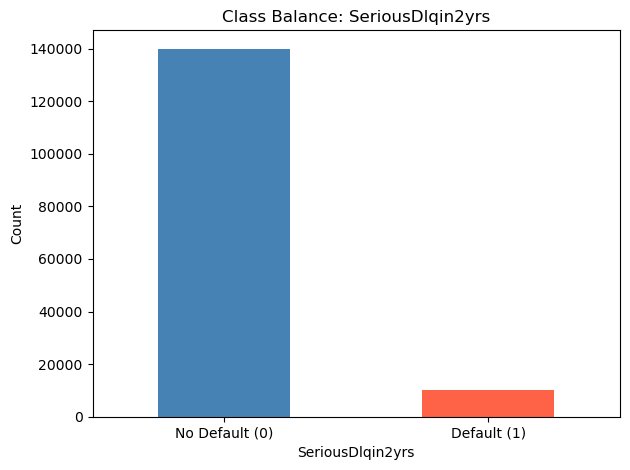

In [6]:
# Let's see how imalanced the target column is
print(df["SeriousDlqin2yrs"].value_counts())
print("\nClass proportions:")
print(df["SeriousDlqin2yrs"].value_counts(normalize=True).round(4))

df["SeriousDlqin2yrs"].value_counts().plot(
    kind="bar",
    title="Class Balance: SeriousDlqin2yrs",
    color = ['steelblue', 'tomato']
)

plt.xticks([0,1], ['No Default (0)', 'Default (1)'], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

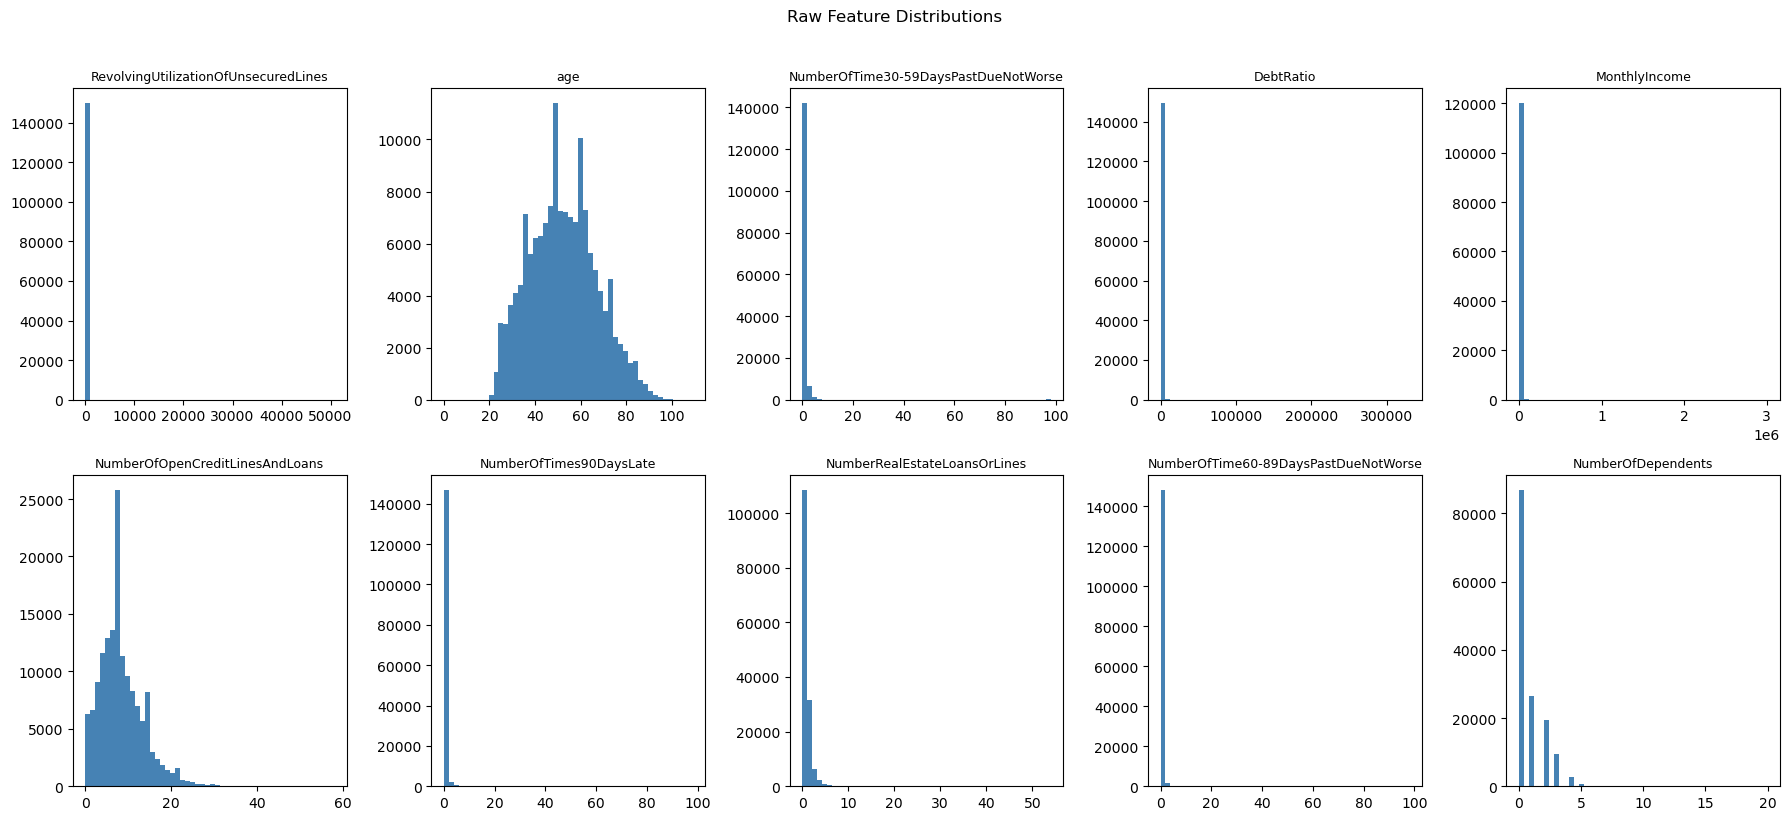

In [7]:
# Cell 1C — Feature Distributions
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat].dropna(), bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Raw Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()


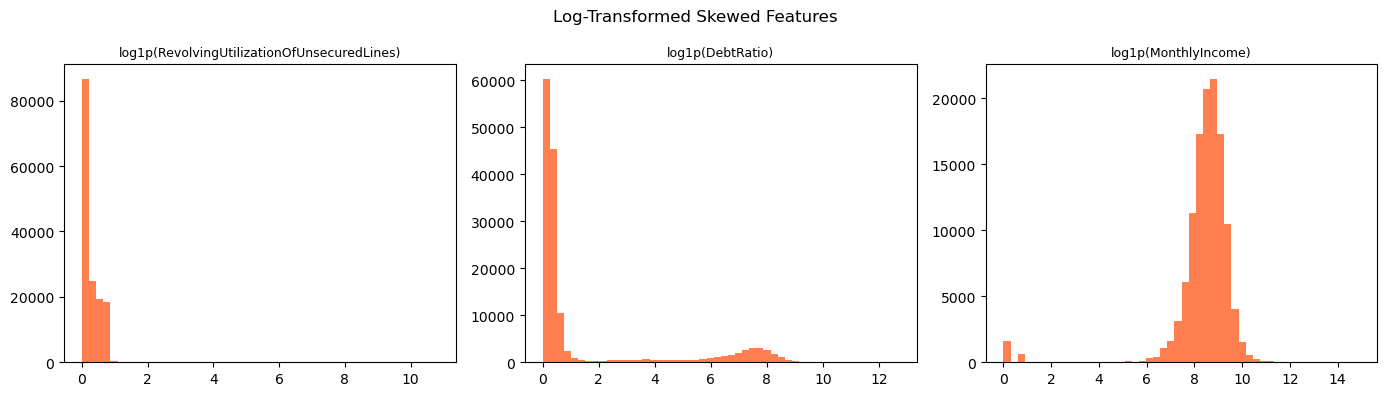

In [8]:
# Log-transform the 3 skewed features to see their actual distribution
skewed = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, feat in enumerate(skewed):
    axes[i].hist(np.log1p(df[feat].dropna()), bins=50, color='coral', edgecolor='none')
    axes[i].set_title(f'log1p({feat})', fontsize=9)

plt.suptitle('Log-Transformed Skewed Features')
plt.tight_layout()
plt.show()


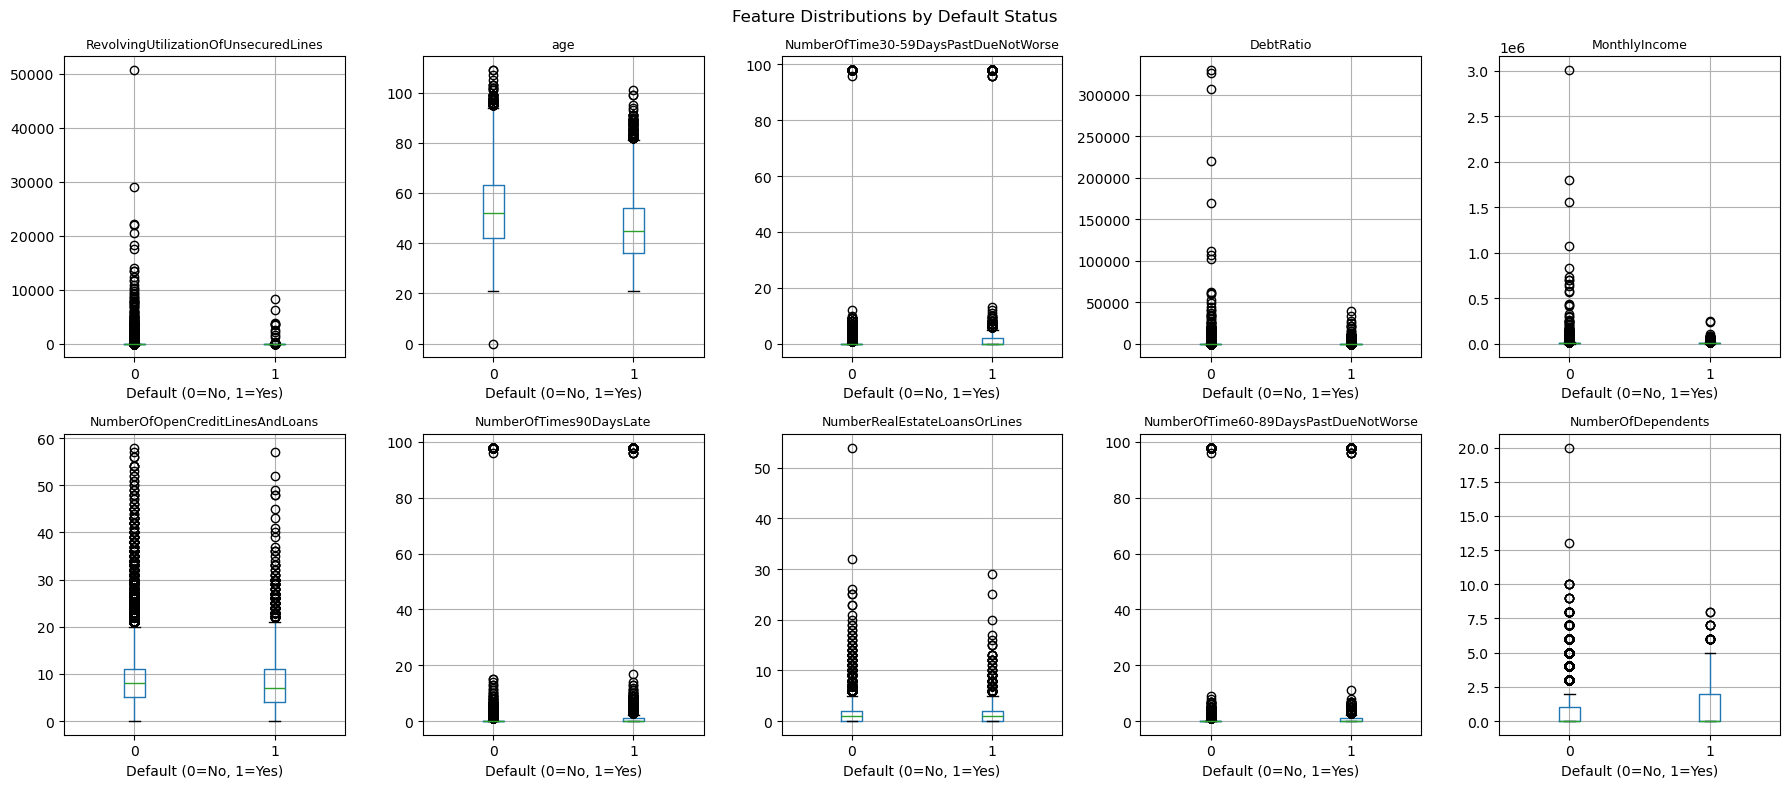

In [10]:
# Cell 1D — Boxplots by Target Class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='SeriousDlqin2yrs', ax=axes[i])
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Default (0=No, 1=Yes)')

plt.suptitle('Feature Distributions by Default Status')
plt.tight_layout()
plt.show()


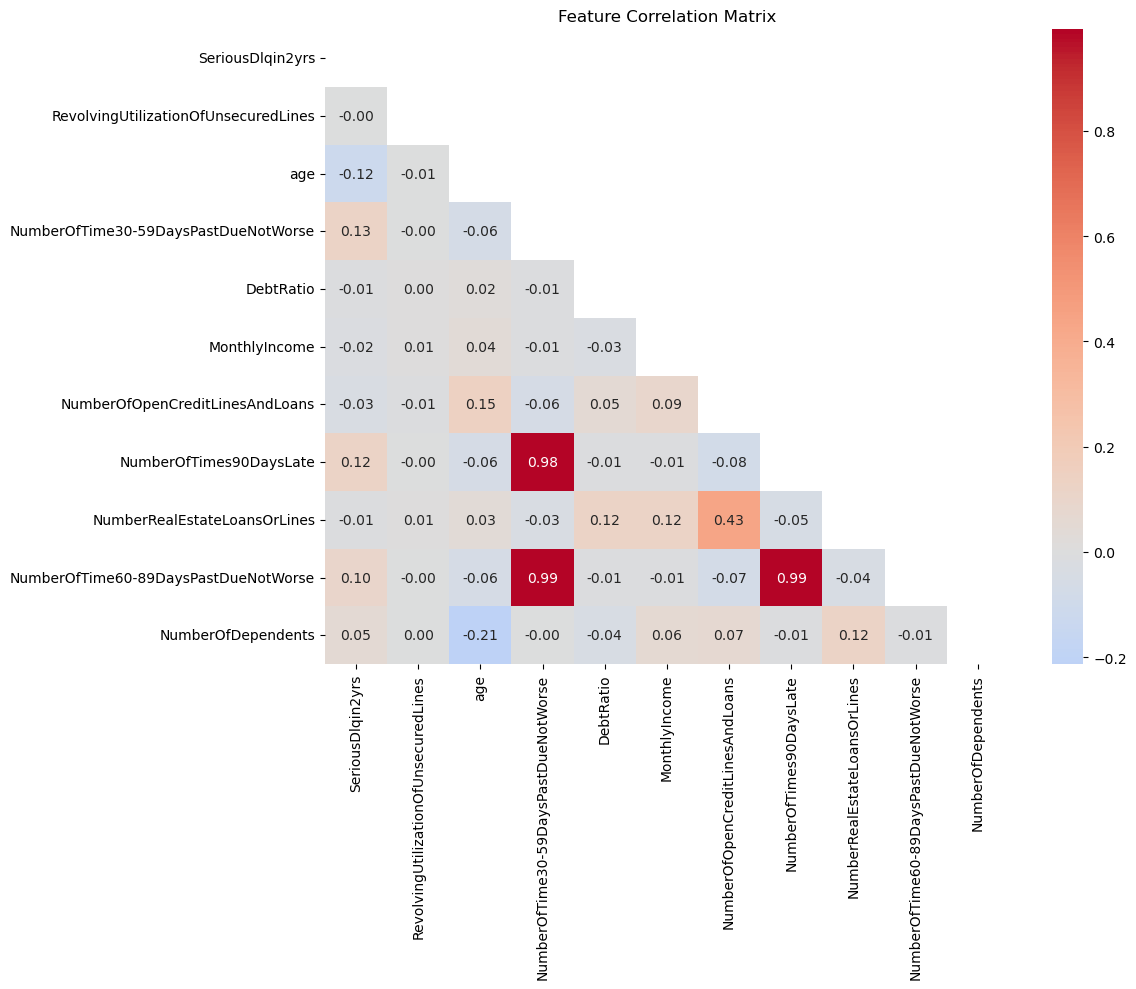

In [11]:
# Correlation Heatmap
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [12]:
# Cell 1F — Missingness Pattern
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isna().astype(int)

print("Default rate where MonthlyIncome is PRESENT:")
print(df[df['MonthlyIncome_missing'] == 0]['SeriousDlqin2yrs'].mean().round(4))

print("\nDefault rate where MonthlyIncome is MISSING:")
print(df[df['MonthlyIncome_missing'] == 1]['SeriousDlqin2yrs'].mean().round(4))


Default rate where MonthlyIncome is PRESENT:
0.0695

Default rate where MonthlyIncome is MISSING:
0.0561


### Section 2: Prerpocessing

In [ ]:
# Outlier Treatment
# Drop bad age rows first
df = df[df['age'] > 0].copy()
print(f"Rows after dropping age==0: {len(df)}")



Rows after dropping age==0: 149999
RevolvingUtilizationOfUnsecuredLines capped at 1.09
DebtRatio capped at 4979.00
NumberOfTime30-59DaysPastDueNotWorse capped at 10
NumberOfTimes90DaysLate capped at 10
NumberOfTime60-89DaysPastDueNotWorse capped at 10

Final shape: (149999, 12)


In [16]:
print(df['DebtRatio'].quantile(0.99))

4979.000032
